In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [10]:
import requests
import pandas as pd
import time

def get_moex_history_safe(secid, start, end):
    """
    Загружает дневные данные (цены закрытия и объём) с MOEX ISS.
    Возвращает DataFrame с колонками 'TRADEDATE', 'CLOSE', 'VOLUME_RUB'.
    """
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/{secid}.json"
    params = {
        'from': start,
        'till': end,
        'limit': 10000
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        # Проверяем наличие ключей
        if 'history' not in data or 'data' not in data['history'] or 'columns' not in data['history']:
            print(f"  Нет данных для {secid} (неверная структура JSON)")
            return pd.DataFrame()
        
        columns = data['history']['columns']
        rows = data['history']['data']
        
        if not rows:
            print(f"  Нет строк данных для {secid}")
            return pd.DataFrame()
        
        df = pd.DataFrame(rows, columns=columns)
        
        # Оставляем нужные колонки: дата, цена закрытия, объём в рублях (VALUE) или считаем сами
        if 'TRADEDATE' not in df.columns or 'CLOSE' not in df.columns:
            print(f"  Отсутствуют обязательные колонки для {secid}")
            return pd.DataFrame()
        
        df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
        df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
        
        # Объём в рублях: берём колонку 'VALUE' (уже рублёвый объём), если нет – умножаем CLOSE на VOLUME
        if 'VALUE' in df.columns:
            df['VOLUME_RUB'] = pd.to_numeric(df['VALUE'], errors='coerce')
        else:
            if 'VOLUME' not in df.columns:
                print(f"  Нет данных об объёме для {secid}")
                return pd.DataFrame()
            df['VOLUME'] = pd.to_numeric(df['VOLUME'], errors='coerce')
            df['VOLUME_RUB'] = df['CLOSE'] * df['VOLUME']
        
        df = df[['TRADEDATE', 'CLOSE', 'VOLUME_RUB']].dropna()
        return df
    
    except Exception as e:
        print(f"  Ошибка при запросе {secid}: {e}")
        return pd.DataFrame()

In [11]:
start = '2015-01-01'
end = '2025-12-31'
threshold = 100_000_000

# Список тикеров (расширенный, но можно начать с этого)
tickers = [
    'SBER', 'VTBR', 'LKOH', 'GAZP', 'ROSN', 'NVTK', 'TATN', 'GMKN', 'CHMF', 'NLMK',
    'PLZL', 'MGNT', 'YNDX', 'MTSS', 'HYDR', 'IRAO', 'PHOR', 'AKRN', 'AFLT', 'PIKK',
    'TRNFP', 'MOEX', 'RUAL', 'ALRS', 'DSKY', 'BELU', 'BANEP', 'FEES', 'MAGN', 'UPRO'
]

results = []

for ticker in tickers:
    print(f"Загрузка {ticker}...")
    df = get_moex_history_safe(ticker, start, end)
    if df.empty:
        continue
    avg_volume = df['VOLUME_RUB'].mean() / 1_000_000   # в млн руб.
    median_volume = df['VOLUME_RUB'].median() / 1_000_000
    results.append({
        'ticker': ticker,
        'avg_volume_mln': avg_volume,
        'median_volume_mln': median_volume,
        'above_threshold': avg_volume >= threshold / 1_000_000
    })
    time.sleep(0.2)  # пауза, чтобы не перегружать сервер

df_volumes = pd.DataFrame(results)
df_volumes = df_volumes.sort_values('avg_volume_mln', ascending=False)
selected = df_volumes[df_volumes['above_threshold']].copy()

print(f"\nОтобрано {len(selected)} акций:")
print(selected[['ticker', 'avg_volume_mln']].round(2))
selected.to_csv('selected_stocks.csv', index=False)

Загрузка SBER...
Загрузка VTBR...
Загрузка LKOH...
Загрузка GAZP...
Загрузка ROSN...
Загрузка NVTK...
Загрузка TATN...
Загрузка GMKN...
Загрузка CHMF...
Загрузка NLMK...
Загрузка PLZL...
Загрузка MGNT...
Загрузка YNDX...
Загрузка MTSS...
Загрузка HYDR...
Загрузка IRAO...
Загрузка PHOR...
Загрузка AKRN...
Загрузка AFLT...
Загрузка PIKK...
Загрузка TRNFP...
Загрузка MOEX...
Загрузка RUAL...
Загрузка ALRS...
Загрузка DSKY...
Загрузка BELU...
Загрузка BANEP...
Загрузка FEES...
Загрузка MAGN...
Загрузка UPRO...

Отобрано 19 акций:
   ticker  avg_volume_mln
0    SBER         9811.27
3    GAZP         5372.98
2    LKOH         3158.84
7    GMKN         2431.10
1    VTBR         2049.36
11   MGNT         1492.76
4    ROSN         1290.50
13   MTSS          680.57
8    CHMF          663.26
5    NVTK          640.45
6    TATN          593.60
23   ALRS          544.67
21   MOEX          479.74
20  TRNFP          417.82
14   HYDR          322.88
28   MAGN          322.61
9    NLMK          220.63


In [12]:
tickers_extended = [
    # Уже проверенные (можно оставить, но они уже есть в твоём CSV)
    'SBER', 'VTBR', 'LKOH', 'GAZP', 'ROSN', 'NVTK', 'TATN', 'GMKN', 'CHMF', 'NLMK',
    'PLZL', 'MGNT', 'YNDX', 'MTSS', 'HYDR', 'IRAO', 'PHOR', 'AKRN', 'AFLT', 'PIKK',
    'TRNFP', 'MOEX', 'RUAL', 'ALRS', 'DSKY', 'BELU', 'BANEP', 'FEES', 'MAGN', 'UPRO',
    # Новые кандидаты (многие из них входят в базу расчёта IMOEX)
    'RSTI', 'MVID', 'SMLT', 'ENPG', 'TGKA', 'MSNG', 'LENT', 'WUSH', 'GCHE', 'SVAV',
    'KMAZ', 'UNAC', 'VSMO', 'KZOS', 'LPSB', 'NFAZ', 'OMZZ', 'PRMB', 'RTKM', 'RZSB',
    'SELG', 'SIBN', 'SNGS', 'TASB', 'TGKB', 'TORSP', 'TRMK', 'UFGS', 'URKA', 'USBN'
]

In [13]:
new_results = []
for ticker in tickers_extended:
    if ticker in df_volumes['ticker'].values:
        continue  # уже есть в предыдущих 19
    print(f"Проверяем {ticker}...")
    df = get_moex_history_safe(ticker, start, end)
    if df.empty:
        continue
    avg_volume = df['VOLUME_RUB'].mean() / 1_000_000
    if avg_volume >= threshold / 1_000_000:
        median_volume = df['VOLUME_RUB'].median() / 1_000_000
        new_results.append({
            'ticker': ticker,
            'avg_volume_mln': avg_volume,
            'median_volume_mln': median_volume,
            'above_threshold': True
        })
    time.sleep(0.2)

df_new = pd.DataFrame(new_results)
df_combined = pd.concat([df_volumes, df_new], ignore_index=True)
df_combined = df_combined.sort_values('avg_volume_mln', ascending=False)
df_combined.to_csv('selected_stocks_combined.csv', index=False)
print(f"Всего отобрано {len(df_combined)} акций")

Проверяем RSTI...
Проверяем MVID...
Проверяем SMLT...
Проверяем ENPG...
Проверяем TGKA...
Проверяем MSNG...
Проверяем LENT...
Проверяем WUSH...
Проверяем GCHE...
Проверяем SVAV...
Проверяем KMAZ...
Проверяем UNAC...
Проверяем VSMO...
Проверяем KZOS...
Проверяем LPSB...
Проверяем NFAZ...
Проверяем OMZZ...
  Нет строк данных для OMZZ
Проверяем PRMB...
Проверяем RTKM...
Проверяем RZSB...
Проверяем SELG...
Проверяем SIBN...
Проверяем SNGS...
Проверяем TASB...
Проверяем TGKB...
Проверяем TORSP...
Проверяем TRMK...
Проверяем UFGS...
  Нет строк данных для UFGS
Проверяем URKA...
Проверяем USBN...
Всего отобрано 35 акций


In [14]:
# Создаём список тикеров для финального набора
final_tickers = [
    'SBER','GAZP','LKOH','GMKN','VTBR','MGNT','ROSN','SNGS','MTSS','CHMF',
    'NVTK','TATN','URKA','ALRS','MOEX','TRNFP','HYDR','MAGN','NLMK','FEES',
    'RTKM','AFLT','WUSH','RSTI','IRAO'
]
# Фильтруем df_combined
df_final = df_combined[df_combined['ticker'].isin(final_tickers)].copy()
df_final = df_final.sort_values('avg_volume_mln', ascending=False)
df_final.to_csv('selected_stocks_final_25.csv', index=False)
print(df_final[['ticker', 'avg_volume_mln']])


   ticker  avg_volume_mln
0    SBER     9811.272847
1    GAZP     5372.976113
2    LKOH     3158.843783
3    GMKN     2431.099611
4    VTBR     2049.363532
5    MGNT     1492.758325
6    ROSN     1290.501701
33   SNGS      983.821173
7    MTSS      680.567643
8    CHMF      663.261723
9    NVTK      640.445388
10   TATN      593.596904
34   URKA      561.619055
11   ALRS      544.665286
12   MOEX      479.744610
13  TRNFP      417.815873
14   HYDR      322.877731
15   MAGN      322.613279
16   NLMK      220.626264
17   FEES      198.096336
32   RTKM      181.013444
18   AFLT      171.680681
31   WUSH      111.412760
30   RSTI      107.199970
19   IRAO       91.874122


In [17]:
import requests
import pandas as pd
import time

# ---------- Функция для получения данных с MOEX ----------
def get_moex_history_safe(secid, start, end):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/{secid}.json"
    params = {'from': start, 'till': end, 'limit': 10000}
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        if 'history' not in data or 'data' not in data['history'] or 'columns' not in data['history']:
            return pd.DataFrame()
        columns = data['history']['columns']
        rows = data['history']['data']
        if not rows:
            return pd.DataFrame()
        df = pd.DataFrame(rows, columns=columns)
        if 'TRADEDATE' not in df.columns or 'CLOSE' not in df.columns:
            return pd.DataFrame()
        df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
        df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')
        if 'VALUE' in df.columns:
            df['VOLUME_RUB'] = pd.to_numeric(df['VALUE'], errors='coerce')
        else:
            if 'VOLUME' not in df.columns:
                return pd.DataFrame()
            df['VOLUME'] = pd.to_numeric(df['VOLUME'], errors='coerce')
            df['VOLUME_RUB'] = df['CLOSE'] * df['VOLUME']
        df = df[['TRADEDATE', 'CLOSE', 'VOLUME_RUB']].dropna()
        return df
    except Exception:
        return pd.DataFrame()

# ---------- Параметры ----------
start_date = '2015-01-01'
end_date = '2025-12-31'
threshold = 100_000_000  # 100 млн руб.

# ---------- Загружаем уже имеющиеся данные ----------
try:
    df_existing = pd.read_csv('selected_stocks_combined.csv')
    # Оставляем только те, у которых above_threshold == True
    df_existing = df_existing[df_existing['above_threshold'] == True].copy()
    print(f"Загружено {len(df_existing)} существующих акций, прошедших порог.")
except FileNotFoundError:
    df_existing = pd.DataFrame()
    print("Файл selected_stocks_combined.csv не найден, начинаем с пустого списка.")

# ---------- Список кандидатов ----------
candidates = ['PIKK', 'POLY', 'TCSG', 'PHOR', 'AKRN', 'KMAZ', 'AGRO', 'LENT']
new_results = []

for ticker in candidates:
    if ticker in df_existing['ticker'].values:
        print(f"{ticker} уже есть в списке, пропускаем.")
        continue
    print(f"Проверяем {ticker}...")
    df = get_moex_history_safe(ticker, start_date, end_date)
    if df.empty:
        print(f"  Нет данных для {ticker}")
        continue
    avg_volume = df['VOLUME_RUB'].mean() / 1_000_000
    if avg_volume >= threshold / 1_000_000:
        median_volume = df['VOLUME_RUB'].median() / 1_000_000
        new_results.append({
            'ticker': ticker,
            'avg_volume_mln': avg_volume,
            'median_volume_mln': median_volume,
            'above_threshold': True
        })
        print(f"  {ticker} ПРОШЁЛ! Средний объём: {avg_volume:.2f} млн руб.")
    else:
        print(f"  {ticker} не прошёл ({avg_volume:.2f} млн руб.)")
    time.sleep(0.2)

# ---------- Объединяем и сохраняем ----------
df_new = pd.DataFrame(new_results)
df_combined = pd.concat([df_existing, df_new], ignore_index=True)
df_combined = df_combined.sort_values('avg_volume_mln', ascending=False)

# Фильтруем только прошедших порог
df_final = df_combined[df_combined['above_threshold'] == True].copy()

df_final.to_csv('selected_stocks_final_30.csv', index=False)

print(f"\nВсего отобрано акций: {len(df_final)}")
print("Список тикеров:")
print(df_final['ticker'].tolist())

Загружено 24 существующих акций, прошедших порог.
Проверяем PIKK...
  PIKK не прошёл (21.27 млн руб.)
Проверяем POLY...
  POLY не прошёл (14.65 млн руб.)
Проверяем TCSG...
  TCSG ПРОШЁЛ! Средний объём: 244.57 млн руб.
Проверяем PHOR...
  PHOR не прошёл (14.80 млн руб.)
Проверяем AKRN...
  AKRN не прошёл (32.91 млн руб.)
Проверяем KMAZ...
  KMAZ не прошёл (9.66 млн руб.)
Проверяем AGRO...
  AGRO не прошёл (0.47 млн руб.)
Проверяем LENT...
  LENT не прошёл (6.98 млн руб.)

Всего отобрано акций: 25
Список тикеров:
['SBER', 'GAZP', 'LKOH', 'GMKN', 'VTBR', 'MGNT', 'ROSN', 'SNGS', 'MTSS', 'CHMF', 'NVTK', 'TATN', 'URKA', 'ALRS', 'MOEX', 'TRNFP', 'HYDR', 'MAGN', 'TCSG', 'NLMK', 'FEES', 'RTKM', 'AFLT', 'WUSH', 'RSTI']


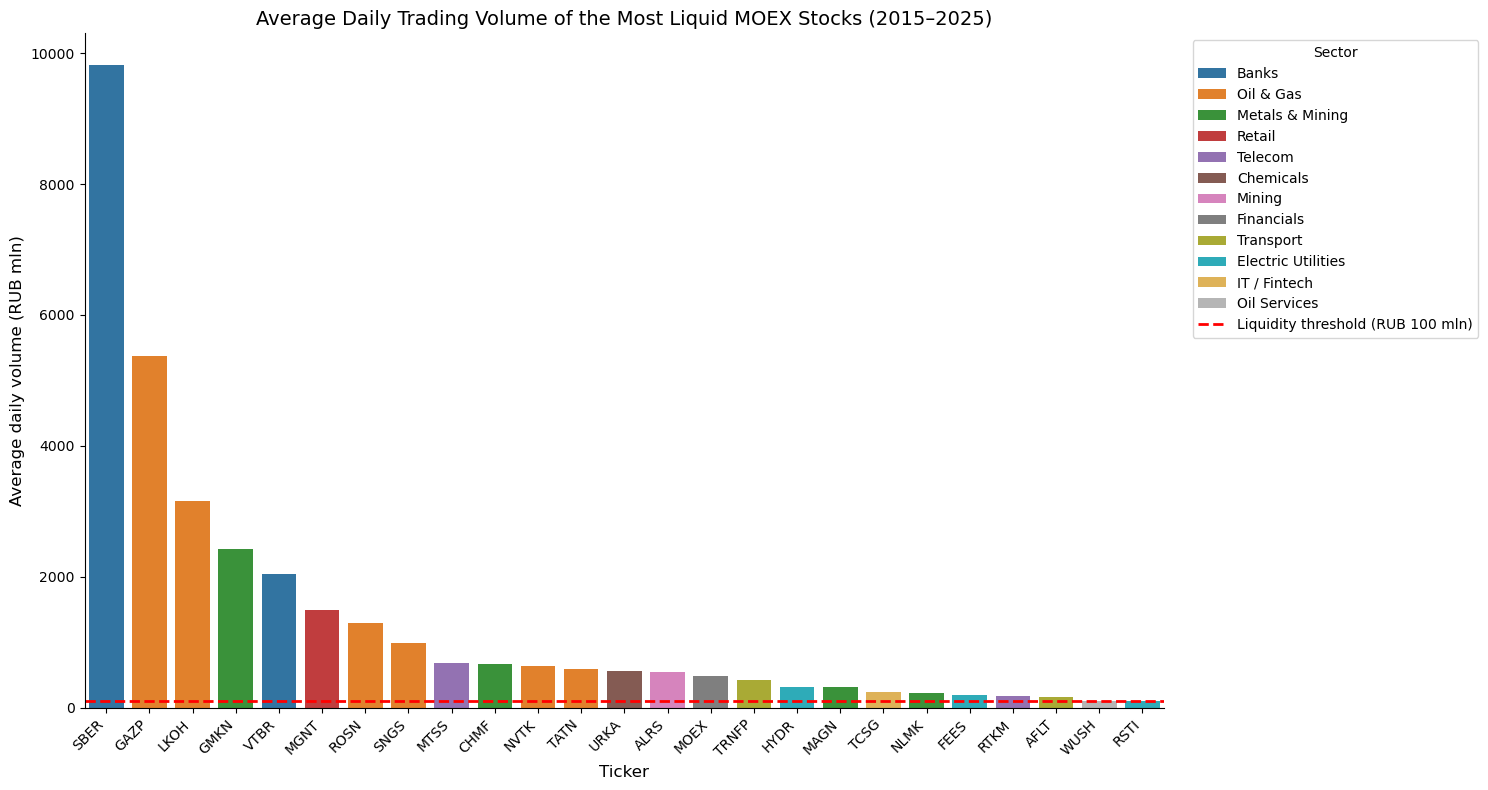

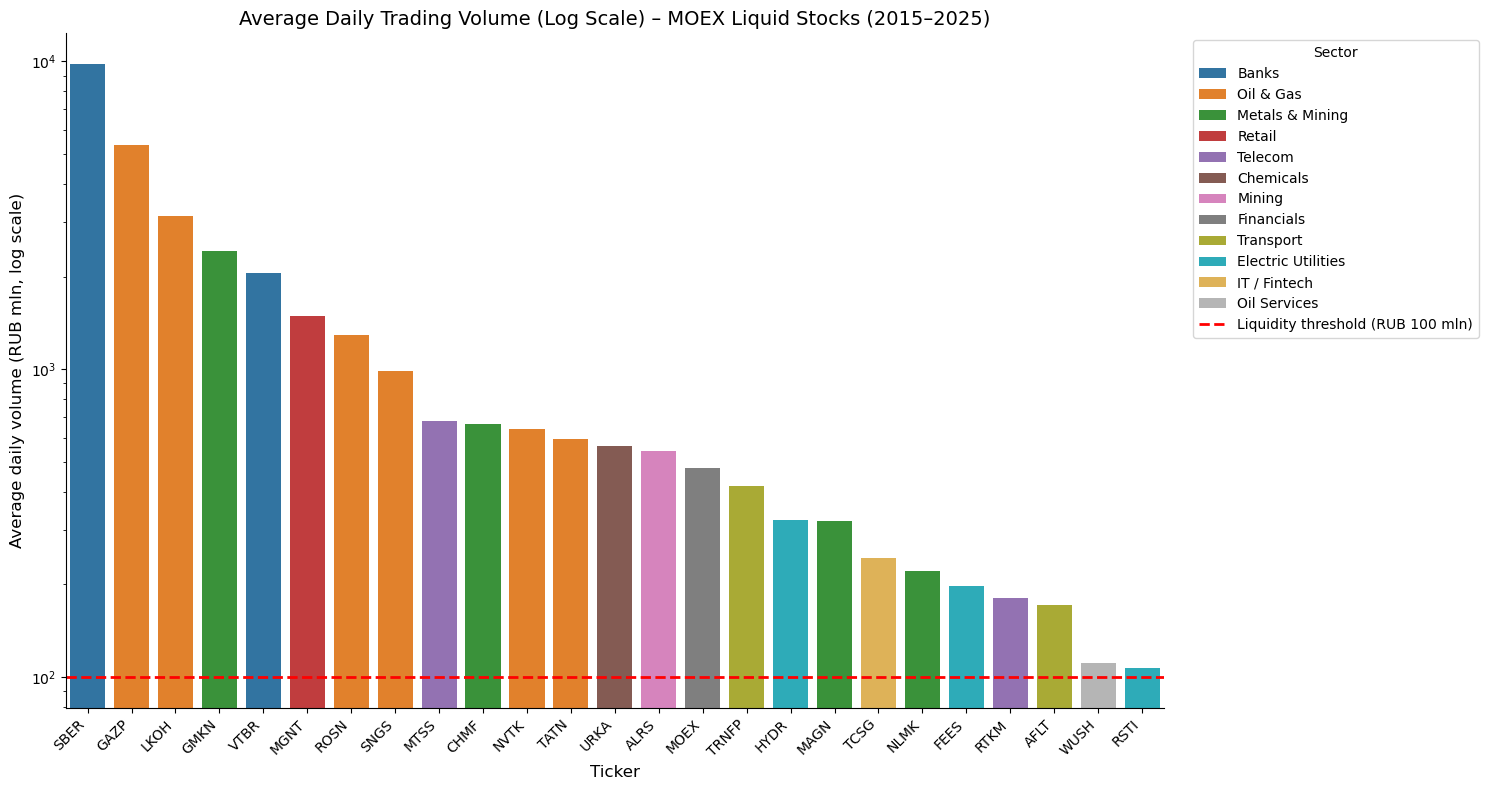

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
df = pd.read_csv('selected_stocks_final_30.csv')
df = df.sort_values('avg_volume_mln', ascending=False)

# Сектора (английские названия)
sector_map = {
    'SBER': 'Banks', 'VTBR': 'Banks',
    'GAZP': 'Oil & Gas', 'LKOH': 'Oil & Gas', 'ROSN': 'Oil & Gas', 'SNGS': 'Oil & Gas', 'NVTK': 'Oil & Gas', 'TATN': 'Oil & Gas',
    'GMKN': 'Metals & Mining', 'CHMF': 'Metals & Mining', 'MAGN': 'Metals & Mining', 'NLMK': 'Metals & Mining',
    'MGNT': 'Retail',
    'MTSS': 'Telecom', 'RTKM': 'Telecom',
    'URKA': 'Chemicals',
    'ALRS': 'Mining',
    'MOEX': 'Financials',
    'TRNFP': 'Transport',
    'HYDR': 'Electric Utilities', 'FEES': 'Electric Utilities', 'RSTI': 'Electric Utilities',
    'TCSG': 'IT / Fintech',
    'AFLT': 'Transport',
    'WUSH': 'Oil Services'
}
df['sector'] = df['ticker'].map(sector_map)

# Цветовая палитра (можно оставить или поменять)
palette = {
    'Banks': '#1f77b4', 'Oil & Gas': '#ff7f0e', 'Metals & Mining': '#2ca02c',
    'Retail': '#d62728', 'Telecom': '#9467bd', 'Chemicals': '#8c564b',
    'Mining': '#e377c2', 'Financials': '#7f7f7f', 'Transport': '#bcbd22',
    'Electric Utilities': '#17becf', 'IT / Fintech': '#f4b942', 'Oil Services': '#b5b5b5'
}

# ---------- 1. Линейный график ----------
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=df, x='ticker', y='avg_volume_mln', hue='sector', palette=palette, dodge=False)
plt.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Liquidity threshold (RUB 100 mln)')
plt.title('Average Daily Trading Volume of the Most Liquid MOEX Stocks (2015–2025)', fontsize=14)
plt.xlabel('Ticker', fontsize=12)
plt.ylabel('Average daily volume (RUB mln)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Sector')
sns.despine()
plt.tight_layout()
plt.savefig('liquidity_linear.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------- 2. Логарифмический график ----------
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=df, x='ticker', y='avg_volume_mln', hue='sector', palette=palette, dodge=False)
plt.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Liquidity threshold (RUB 100 mln)')
plt.yscale('log')
plt.title('Average Daily Trading Volume (Log Scale) – MOEX Liquid Stocks (2015–2025)', fontsize=14)
plt.xlabel('Ticker', fontsize=12)
plt.ylabel('Average daily volume (RUB mln, log scale)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Sector')
sns.despine()
plt.tight_layout()
plt.savefig('liquidity_logscale.png', dpi=300, bbox_inches='tight')
plt.show()